# Hệ thống hỏi đáp tiếng Việt trên miền tri thức luật giao thông

Notebook đã được tối ưu cho file `Dataset_6000.csv` trong folder `archive`.

Điểm chính:
- Dùng trực tiếp 6,820 cặp QA có sẵn
- RAG bằng FAISS + multilingual-e5-small
- Fine-tune LoRA/QLoRA với config nhẹ cho Colab Free
- So sánh 4 cấu hình A/B/C/D
- Đánh giá BLEU, ROUGE-L, BERTScore, Recall@5, human eval 50 câu

In [3]:
!pip -q install -U transformers accelerate peft bitsandbytes trl datasets evaluate sentence-transformers faiss-cpu rouge_score bert-score pandas tqdm

^C


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy-transformers 1.4.0 requires transformers<4.53.3,>=3.4.0, but you have transformers 5.8.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os, re, ast, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Tự động tìm file CSV
CANDIDATES = [
    Path("archive/Dataset_6000.csv"),
    Path("/mnt/data/archive/Dataset_6000.csv"),
    Path("/mnt/data/Dataset_6000.csv"),
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy Dataset_6000.csv trong archive hoặc /mnt/data.")

WORK_DIR = Path("./trafficlaw_rag")
DATA_DIR = WORK_DIR / "data"
PROC_DIR = DATA_DIR / "processed"
OUT_DIR = WORK_DIR / "outputs"
CACHE_DIR = WORK_DIR / "cache"

# Tạo toàn bộ thư mục (nếu chưa có)
for path in [WORK_DIR, DATA_DIR, PROC_DIR, OUT_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

for path in [WORK_DIR, DATA_DIR, PROC_DIR, OUT_DIR, CACHE_DIR]:
    print(f"{path} -> {'Tồn tại' if path.exists() else 'Chưa có'}")


# Config tối ưu cho Colab Free
BASE_LLM = os.getenv("BASE_LLM", "Qwen/Qwen2.5-0.5B-Instruct")
EMBED_MODEL = os.getenv("EMBED_MODEL", "intfloat/multilingual-e5-small")
MAX_SEQ_LEN = 768
MAX_NEW_TOKENS = 128
TRAIN_EPOCHS = 1
TRAIN_BS = 1
GRAD_ACCUM = 16
LR = 2e-4
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
TOP_K = 5
CHUNK_SIZE = 800
CHUNK_OVERLAP = 120

print("DATA_PATH:", DATA_PATH)
print("BASE_LLM:", BASE_LLM)
print("EMBED_MODEL:", EMBED_MODEL)

trafficlaw_rag -> Tồn tại
trafficlaw_rag\data -> Tồn tại
trafficlaw_rag\data\processed -> Tồn tại
trafficlaw_rag\outputs -> Tồn tại
trafficlaw_rag\cache -> Tồn tại
DATA_PATH: archive\Dataset_6000.csv
BASE_LLM: Qwen/Qwen2.5-0.5B-Instruct
EMBED_MODEL: intfloat/multilingual-e5-small


## 1) Đọc và làm sạch dữ liệu

In [6]:
def safe_read_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, engine="python", encoding="utf-8-sig")

def normalize_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x).replace("\u00a0", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def parse_references(ref_str: str) -> str:
    ref_str = normalize_text(ref_str)
    if not ref_str:
        return ""
    try:
        obj = ast.literal_eval(ref_str)
        if isinstance(obj, (list, tuple)):
            items = []
            for it in obj:
                if isinstance(it, (list, tuple)) and len(it) >= 1:
                    items.append(normalize_text(it[0]))
                else:
                    items.append(normalize_text(it))
            return "; ".join([i for i in items if i])
    except Exception:
        pass
    return ref_str

# Lưu bản gốc để so sánh trước/sau làm sạch
raw_df = safe_read_csv(DATA_PATH)
print("Dữ liệu gốc:", raw_df.shape)
display(raw_df.head())

required = [c for c in ["question", "answer"] if c not in raw_df.columns]
if required:
    raise ValueError(f"Thiếu cột bắt buộc: {required}")

df = raw_df.reset_index(drop=True).copy()
df["original_id"] = df.index.astype(int)

df["question"] = df["question"].apply(normalize_text)
df["answer"] = df["answer"].apply(normalize_text)
df["references_text"] = df["references"].apply(parse_references) if "references" in df.columns else ""
df["request_link"] = df["request_link"].apply(normalize_text) if "request_link" in df.columns else ""

before_rows = len(df)
before_dups = df.duplicated(subset=["question", "answer"]).sum()

df = df[(df["question"].str.len() >= 5) & (df["answer"].str.len() >= 10)].copy()
df = df.drop_duplicates(subset=["question", "answer"]).reset_index(drop=True)

print("Sau làm sạch:", df.shape)
print("Số dòng bị lọc/loại:", before_rows - len(df))
print("Số duplicate trước khi drop:", int(before_dups))
display(df.head())

Dữ liệu gốc: (6820, 4)


,request_link,question,answer,references
0,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,"Từ 01/01/2025, có giấy hẹn lấy giấy đăng ký xe...",Căn cứ theo điểm a khoản 2 Điều 56 Luật trật t...,"[('Điểm a khoản 2 điều 56 Luật trật tự, an toà..."
1,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,Không có giấy đăng ký xe máy khi tham gia giao...,Căn cứ khoản 2 Điều 17 Nghị định 100/2019/NĐ-C...,"[('Khoản 2 điều 17 Nghị định 100/2019/NĐ-CP', ..."
2,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,Độ tuổi được cấp Giấy phép lái xe từ ngày 01/0...,"Căn cứ theo Điều 59 Luật Trật tự, an toàn giao...","[('Điều 59 Luật Trật tự, an toàn giao thông đư..."
3,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,05 biện pháp giải quyết tình huống đột xuất ùn...,"Căn cứ khoản 1 Điều 78 Luật Trật tự, an toàn g...","[('Khoản 1 điều 78 Luật Trật tự, an toàn giao ..."
4,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,"Những tình huống nào được xem là đột xuất, gây...","Căn cứ khoản 1 Điều 76 Luật Trật tự, an toàn g...","[('Khoản 1 điều 76 Luật Trật tự, an toàn giao ..."


Sau làm sạch: (6765, 6)
Số dòng bị lọc/loại: 55
Số duplicate trước khi drop: 53


,request_link,question,answer,references,original_id,references_text
0,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,"Từ 01/01/2025, có giấy hẹn lấy giấy đăng ký xe...",Căn cứ theo điểm a khoản 2 Điều 56 Luật trật t...,"[('Điểm a khoản 2 điều 56 Luật trật tự, an toà...",0,"Điểm a khoản 2 điều 56 Luật trật tự, an toàn g..."
1,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,Không có giấy đăng ký xe máy khi tham gia giao...,Căn cứ khoản 2 Điều 17 Nghị định 100/2019/NĐ-C...,"[('Khoản 2 điều 17 Nghị định 100/2019/NĐ-CP', ...",1,Khoản 2 điều 17 Nghị định 100/2019/NĐ-CP
2,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,Độ tuổi được cấp Giấy phép lái xe từ ngày 01/0...,"Căn cứ theo Điều 59 Luật Trật tự, an toàn giao...","[('Điều 59 Luật Trật tự, an toàn giao thông đư...",2,"Điều 59 Luật Trật tự, an toàn giao thông đường..."
3,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,05 biện pháp giải quyết tình huống đột xuất ùn...,"Căn cứ khoản 1 Điều 78 Luật Trật tự, an toàn g...","[('Khoản 1 điều 78 Luật Trật tự, an toàn giao ...",3,"Khoản 1 điều 78 Luật Trật tự, an toàn giao thô..."
4,https://thuvienphapluat.vn/hoi-dap-phap-luat/8...,"Những tình huống nào được xem là đột xuất, gây...","Căn cứ khoản 1 Điều 76 Luật Trật tự, an toàn g...","[('Khoản 1 điều 76 Luật Trật tự, an toàn giao ...",4,"Khoản 1 điều 76 Luật Trật tự, an toàn giao thô..."


## 1.1) Phân tích dữ liệu trước và sau làm sạch

,stage,rows,duplicate_pairs,missing_values,avg_question_len,avg_answer_len
0,raw_df,6820,52,9,74.970674,1574.226833
1,cleaned_df,6765,0,0,75.053954,1573.786401


,before,after
question,5,0
answer,4,0


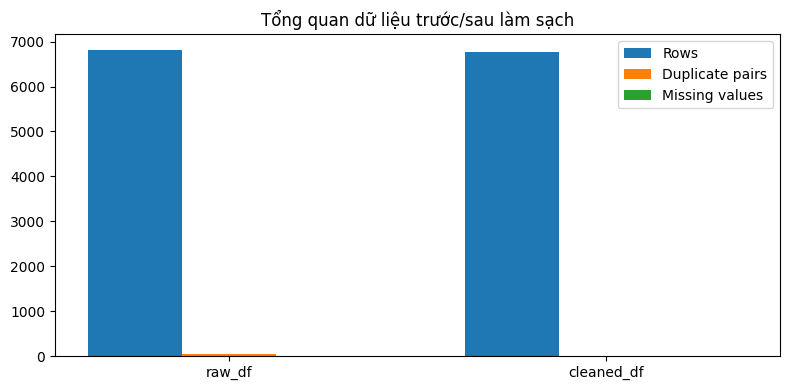

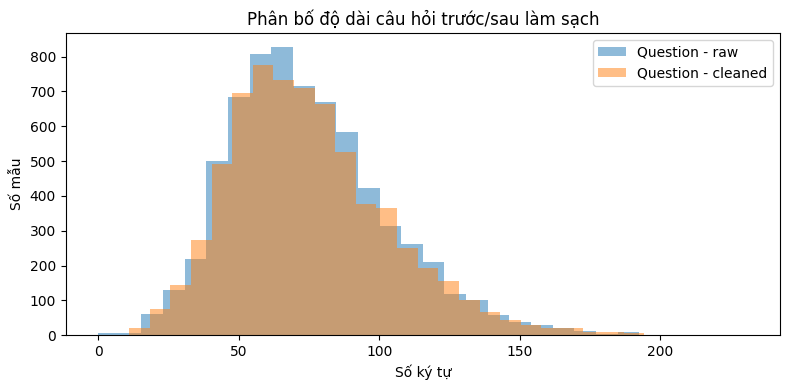

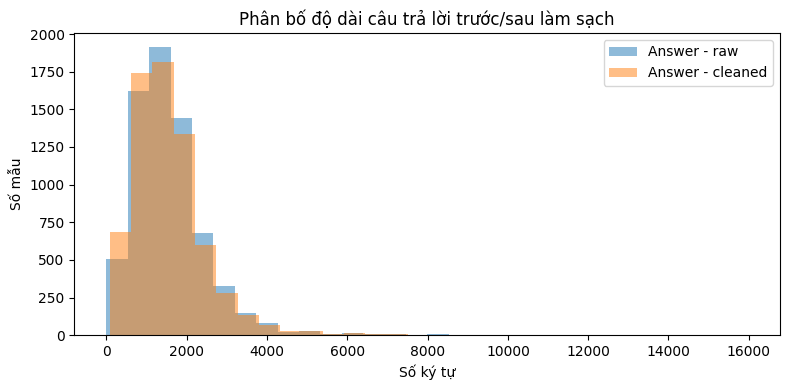

In [7]:
def _length_series(frame: pd.DataFrame, col: str) -> pd.Series:
    return frame[col].fillna("").astype(str).map(len)

def _safe_dup_count(frame: pd.DataFrame) -> int:
    if all(c in frame.columns for c in ["question", "answer"]):
        return int(frame.duplicated(subset=["question", "answer"]).sum())
    return 0

summary_rows = []
summary_rows.append({
    "stage": "raw_df",
    "rows": len(raw_df),
    "duplicate_pairs": _safe_dup_count(raw_df) if "question" in raw_df.columns and "answer" in raw_df.columns else np.nan,
    "missing_values": int(raw_df.isna().sum().sum()),
    "avg_question_len": float(_length_series(raw_df, "question").mean()) if "question" in raw_df.columns else np.nan,
    "avg_answer_len": float(_length_series(raw_df, "answer").mean()) if "answer" in raw_df.columns else np.nan,
})
summary_rows.append({
    "stage": "cleaned_df",
    "rows": len(df),
    "duplicate_pairs": _safe_dup_count(df),
    "missing_values": int(df.isna().sum().sum()),
    "avg_question_len": float(_length_series(df, "question").mean()),
    "avg_answer_len": float(_length_series(df, "answer").mean()),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

missing_before = raw_df.isna().sum().sort_values(ascending=False)
missing_after = df.isna().sum().sort_values(ascending=False)
missing_compare = pd.DataFrame({
    "before": missing_before,
    "after": missing_after.reindex(missing_before.index).fillna(0).astype(int),
})
missing_compare = missing_compare[(missing_compare["before"] > 0) | (missing_compare["after"] > 0)]
if not missing_compare.empty:
    display(missing_compare)

fig, ax = plt.subplots(figsize=(8, 4))
stages = summary_df["stage"].tolist()
x = np.arange(len(stages))
width = 0.25
ax.bar(x - width, summary_df["rows"], width, label="Rows")
ax.bar(x, summary_df["duplicate_pairs"].fillna(0), width, label="Duplicate pairs")
ax.bar(x + width, summary_df["missing_values"], width, label="Missing values")
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_title("Tổng quan dữ liệu trước/sau làm sạch")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_length_series(raw_df, "question"), bins=30, alpha=0.5, label="Question - raw")
ax.hist(_length_series(df, "question"), bins=30, alpha=0.5, label="Question - cleaned")
ax.set_title("Phân bố độ dài câu hỏi trước/sau làm sạch")
ax.set_xlabel("Số ký tự")
ax.set_ylabel("Số mẫu")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_length_series(raw_df, "answer"), bins=30, alpha=0.5, label="Answer - raw")
ax.hist(_length_series(df, "answer"), bins=30, alpha=0.5, label="Answer - cleaned")
ax.set_title("Phân bố độ dài câu trả lời trước/sau làm sạch")
ax.set_xlabel("Số ký tự")
ax.set_ylabel("Số mẫu")
ax.legend()
plt.tight_layout()
plt.show()

## 2) Chia train / val / test và tạo mẫu test thủ công 50 câu

In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Tạo nhãn tham chiếu để phần đánh giá chạy ổn định hơn
for split_df in [train_df, val_df, test_df]:
    split_df["reference_answer"] = split_df["answer"]
    split_df["gold_chunk_id"] = split_df["original_id"].apply(lambda x: f"{int(x)}_0")

train_df.to_csv(PROC_DIR / "train.csv", index=False, encoding="utf-8-sig")
val_df.to_csv(PROC_DIR / "val.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(PROC_DIR / "test.csv", index=False, encoding="utf-8-sig")
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("Tỉ lệ:", round(len(train_df)/len(df), 4), round(len(val_df)/len(df), 4), round(len(test_df)/len(df), 4))

train/val/test: 5412 676 677
Tỉ lệ: 0.8 0.0999 0.1001


## 2.1) Phân tích train / val / test

,split,count,ratio
0,train,5412,0.800000
1,val,676,0.099926
2,test,677,0.100074


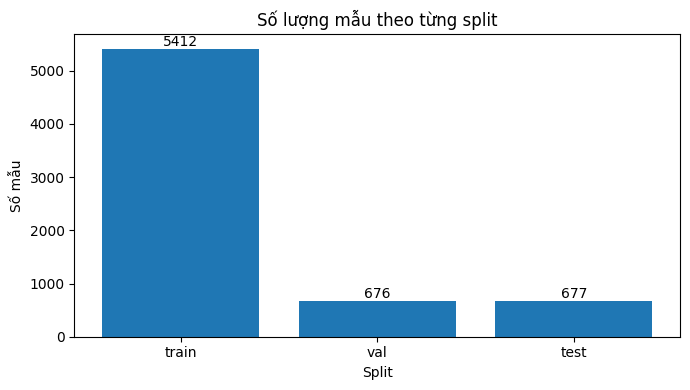

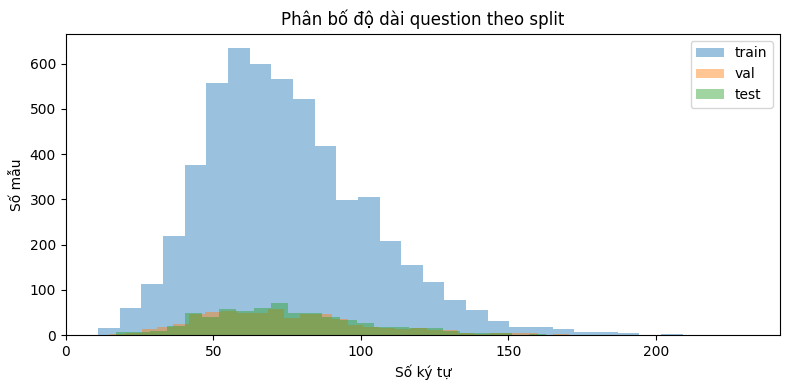

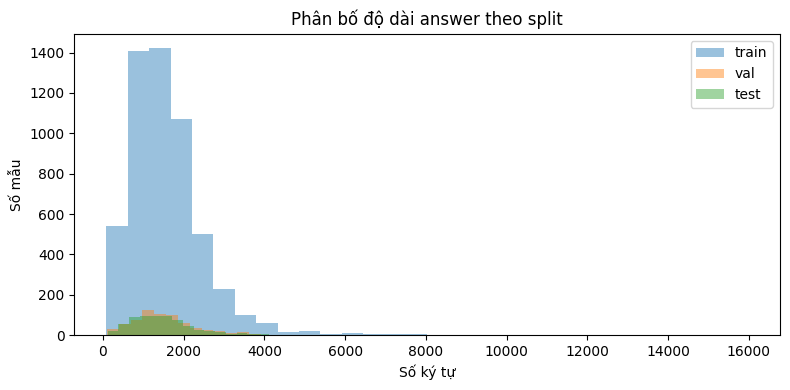

In [6]:
split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "count": [len(train_df), len(val_df), len(test_df)],
})
split_summary["ratio"] = split_summary["count"] / split_summary["count"].sum()
display(split_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_summary["split"], split_summary["count"])
ax.set_title("Số lượng mẫu theo từng split")
ax.set_xlabel("Split")
ax.set_ylabel("Số mẫu")
for i, v in enumerate(split_summary["count"]):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

def plot_length_by_split(column: str, bins: int = 30):
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]:
        vals = frame[column].fillna("").astype(str).map(len)
        ax.hist(vals, bins=bins, alpha=0.45, label=name)
    ax.set_title(f"Phân bố độ dài {column} theo split")
    ax.set_xlabel("Số ký tự")
    ax.set_ylabel("Số mẫu")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_length_by_split("question")
plot_length_by_split("answer")

## 3) Xây knowledge base cho RAG

In [9]:
def build_source_text(row: pd.Series) -> str:
    parts = []
    q = normalize_text(row.get("question", ""))
    a = normalize_text(row.get("answer", ""))
    r = normalize_text(row.get("references_text", ""))
    link = normalize_text(row.get("request_link", ""))
    if q: parts.append(f"Câu hỏi: {q}")
    if a: parts.append(f"Trả lời: {a}")
    if r: parts.append(f"Tham khảo: {r}")
    if link: parts.append(f"Nguồn: {link}")
    return "\n".join(parts).strip()

def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> List[str]:
    text = normalize_text(text)
    if len(text) <= chunk_size:
        return [text] if text else []
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end].strip()
        if len(chunk) >= 50:
            chunks.append(chunk)
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks

corpus_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Build corpus"):
    chunks = chunk_text(build_source_text(row))
    for j, ch in enumerate(chunks):
        corpus_rows.append({"source_row_id": int(row["original_id"]), "chunk_id": f"{int(row['original_id'])}_{j}", "chunk_idx": j, "text": ch})

corpus_df = pd.DataFrame(corpus_rows)
corpus_df.to_csv(PROC_DIR / "corpus_chunks.csv", index=False, encoding="utf-8-sig")
print("Corpus chunks:", len(corpus_df))
display(corpus_df.head())

Build corpus:   0%|          | 0/6765 [00:00<?, ?it/s]

Corpus chunks: 20998


,source_row_id,chunk_id,chunk_idx,text
0,0,0_0,0,"Câu hỏi: Từ 01/01/2025, có giấy hẹn lấy giấy đ..."
1,0,0_1,1,i xe phải mang theo các giấy tờ sau đây: a) Ch...
2,0,0_2,2,xe có chứng thực kèm bản gốc giấy tờ xác nhận ...
3,1,1_0,0,Câu hỏi: Không có giấy đăng ký xe máy khi tham...
4,1,1_1,1,đăng ký xe đã hết hạn sử dụng; [...] 4. Ngoài ...


## 4) Embedding + FAISS

In [10]:
from sentence_transformers import SentenceTransformer
import faiss

embedder = SentenceTransformer(EMBED_MODEL)
EMB_CACHE = CACHE_DIR / "corpus_embeddings.npy"
INDEX_CACHE = CACHE_DIR / "faiss.index"

def build_embeddings(texts: List[str]) -> np.ndarray:
    emb = embedder.encode(texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    return np.asarray(emb, dtype="float32")

if EMB_CACHE.exists() and INDEX_CACHE.exists():
    corpus_emb = np.load(EMB_CACHE)
    index = faiss.read_index(str(INDEX_CACHE))
    print("Loaded cached embeddings/index")
else:
    corpus_emb = build_embeddings(["passage: " + t for t in corpus_df["text"].tolist()])
    index = faiss.IndexFlatIP(corpus_emb.shape[1])
    index.add(corpus_emb)
    np.save(EMB_CACHE, corpus_emb)
    faiss.write_index(index, str(INDEX_CACHE))
    print("Built embeddings/index")

print("Index size:", index.ntotal)

def retrieve_top_k(question: str, k: int = TOP_K) -> List[Dict]:
    q_emb = embedder.encode(["query: " + normalize_text(question)], normalize_embeddings=True)
    q_emb = np.asarray(q_emb, dtype="float32")
    scores, ids = index.search(q_emb, k)
    out = []
    for rank, (score, idx) in enumerate(zip(scores[0], ids[0]), start=1):
        if idx < 0:
            continue
        row = corpus_df.iloc[int(idx)]
        out.append({
            "rank": rank,
            "chunk_id": row["chunk_id"],
            "source_row_id": int(row["source_row_id"]),
            "score": float(score),
            "text": row["text"],
        })
    return out

def recall_at_k(eval_df: pd.DataFrame, k: int = TOP_K) -> float:
    hit, total = 0, 0
    for _, row in eval_df.iterrows():
        q = normalize_text(row["question"])
        gold = normalize_text(row.get("gold_chunk_id", ""))
        if not q or not gold:
            continue
        ids = [x["chunk_id"] for x in retrieve_top_k(q, k=k)]
        hit += int(gold in ids)
        total += 1
    return hit / total if total else float("nan")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ACER\.cache\huggingface\hub\models--intfloat--multilingual-e5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Loaded cached embeddings/index
Index size: 20998


## 5) Prompt template

In [11]:
SYSTEM_PROMPT = (
    "Bạn là trợ lý hỏi đáp tiếng Việt về luật giao thông. "
    "Hãy trả lời ngắn gọn, chính xác, tự nhiên. "
    "Chỉ dựa vào ngữ cảnh được cung cấp. "
    "Nếu ngữ cảnh không đủ, hãy nói rõ là chưa đủ thông tin."
)

def build_messages(question: str, contexts: Optional[List[Dict]] = None, use_rag: bool = False) -> List[Dict]:
    user = f"Câu hỏi: {normalize_text(question)}"
    if use_rag and contexts:
        ctx = []
        for c in contexts:
            ctx.append(f"[Nguồn {c['rank']} | {c['chunk_id']}]\n{c['text']}")
        user += "\n\nNgữ cảnh:\n" + "\n\n".join(ctx)
    user += "\n\nHãy trả lời bằng tiếng Việt."
    return [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user}]

## 6) Fine-tuning LoRA / QLoRA

In [12]:
import os
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

def format_sft_example(question: str, answer: str) -> str:
    return f"""### Câu hỏi:
{question}

### Trả lời:
{answer}"""

def to_sft_dataset(df):
    texts = [format_sft_example(q, a) for q, a in zip(df["question"], df["answer"])]
    return Dataset.from_dict({"text": texts})

train_dataset = to_sft_dataset(train_df)
val_dataset = to_sft_dataset(val_df)

tokenizer = AutoTokenizer.from_pretrained(BASE_LLM, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_LLM,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

MAX_LEN = 768

def tokenize_fn(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

train_tok = train_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok = val_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir= OUT_DIR / "qlora_adapter",
    num_train_epochs=TRAIN_EPOCHS,
    per_device_train_batch_size= TRAIN_BS,
    per_device_eval_batch_size= TRAIN_BS,
    gradient_accumulation_steps= GRAD_ACCUM,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    optim="paged_adamw_8bit",
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ACER\.cache\huggingface\hub\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


Map:   0%|          | 0/5412 [00:00<?, ? examples/s]

Map:   0%|          | 0/676 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [11]:
train_result = trainer.train()

FINAL_ADAPTER_DIR = OUT_DIR / "qlora_adapter_final"
FINAL_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(FINAL_ADAPTER_DIR)
tokenizer.save_pretrained(FINAL_ADAPTER_DIR)
print("Saved adapter to:", FINAL_ADAPTER_DIR)

C:\Users\phang\AppData\Roaming\Python\Python313\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,1.253109,1.278318
200,1.176547,1.171306
300,1.038776,1.135543
339,1.136641,1.134392


C:\Users\phang\AppData\Roaming\Python\Python313\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\phang\AppData\Roaming\Python\Python313\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\p

Saved adapter to: trafficlaw_rag\outputs\qlora_adapter_final


## 6.1) Theo dõi loss trong quá trình fine-tuning

In [13]:
history_df = pd.DataFrame(trainer.state.log_history)

if history_df.empty:
    print("Chưa có log_history từ trainer.")
else:
    display(history_df.tail(10))

    train_logs = history_df[history_df["loss"].notna()].copy()
    eval_logs = history_df[history_df["eval_loss"].notna()].copy()

    if not train_logs.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(train_logs["step"], train_logs["loss"], marker="o")
        ax.set_title("Train loss theo step")
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        plt.tight_layout()
        plt.show()

    if not eval_logs.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval_loss")
        if "eval_runtime" in eval_logs.columns:
            ax2 = ax.twinx()
            ax2.plot(eval_logs["step"], eval_logs["eval_runtime"], marker="x", linestyle="--", label="eval_runtime")
            ax2.set_ylabel("Runtime (s)")
        ax.set_title("Eval loss theo step")
        ax.set_xlabel("Step")
        ax.set_ylabel("Eval loss")
        plt.tight_layout()
        plt.show()

    if "loss" in train_logs.columns:
        print("Train loss cuối:", float(train_logs["loss"].iloc[-1]))
    if "eval_loss" in eval_logs.columns and not eval_logs.empty:
        best_row = eval_logs.loc[eval_logs["eval_loss"].idxmin()]
        print("Eval loss tốt nhất:", float(best_row["eval_loss"]), "tại step", int(best_row["step"]))

Chưa có log_history từ trainer.


## 7) Inference cho 4 cấu hình A/B/C/D

In [ ]:
from transformers import GenerationConfig
from peft import PeftModel

def get_model_device(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_base_model(model_name: str):
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        quantization_config=bnb_config,
        trust_remote_code=True,
    )
    model.eval()
    return tok, model

def load_finetuned_model(model_name: str, adapter_dir: str):
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        quantization_config=bnb_config,
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()
    return tok, model

def build_prompt(tokenizer, question: str, contexts: Optional[List[Dict]] = None, use_rag: bool = False) -> str:
    messages = build_messages(question, contexts=contexts, use_rag=use_rag)
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    prompt = SYSTEM_PROMPT + "\n\n"
    if use_rag and contexts:
        prompt += "Ngữ cảnh:\n"
        for c in contexts:
            prompt += f"[Nguồn {c['rank']} | {c['chunk_id']}]\n{c['text']}\n\n"
    prompt += f"Câu hỏi: {normalize_text(question)}\n\nTrả lời:"
    return prompt

def generate_answer(tokenizer, model, question: str, use_rag: bool = False, k: int = TOP_K) -> Tuple[str, List[Dict]]:
    contexts = retrieve_top_k(question, k=k) if use_rag else []
    prompt = build_prompt(tokenizer, question, contexts=contexts, use_rag=use_rag)
    device = get_model_device(model)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    gen_cfg = GenerationConfig(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        temperature=0.0,
        top_p=1.0,
        pad_token_id=tokenizer.eos_token_id,
    )
    with torch.no_grad():
        out = model.generate(**inputs, generation_config=gen_cfg)

    gen_tokens = out[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

    answer = text
    for marker in ["### Trả lời:", "Trả lời:", "Answer:"]:
        if marker in answer:
            answer = answer.split(marker, 1)[-1].strip()
    return answer.strip(), contexts

## 8) Metrics: BLEU, ROUGE-L, BERTScore

In [ ]:
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def normalize_for_metric(x: str) -> str:
    return normalize_text(x)

def compute_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    preds = [normalize_for_metric(x) for x in preds]
    refs = [normalize_for_metric(x) for x in refs]
    bleu = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])["bleu"]
    rouge = rouge_metric.compute(predictions=preds, references=refs)["rougeL"]
    bs = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="vi",
        model_type="bert-base-multilingual-cased",
        rescale_with_baseline=True,
    )
    return {"BLEU": float(bleu), "ROUGE-L": float(rouge), "BERTScore_F1": float(np.mean(bs["f1"]))}

def token_f1(pred: str, ref: str) -> float:
    pred_tokens = set(normalize_text(pred).lower().split())
    ref_tokens = set(normalize_text(ref).lower().split())
    if not pred_tokens or not ref_tokens:
        return 0.0
    common = pred_tokens & ref_tokens
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def exact_match(pred: str, ref: str) -> float:
    return float(normalize_text(pred).lower() == normalize_text(ref).lower())

def evaluate_model(eval_df: pd.DataFrame, tokenizer, model, config_name: str, use_rag: bool) -> pd.DataFrame:
    rows = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"Eval {config_name}"):
        q = normalize_text(row["question"])
        ref = normalize_text(row.get("reference_answer", row.get("answer", "")))
        gold_chunk = normalize_text(row.get("gold_chunk_id", f"{int(row['original_id'])}_0" if "original_id" in row and pd.notna(row["original_id"]) else ""))
        pred, contexts = generate_answer(tokenizer, model, q, use_rag=use_rag)
        retrieved_ids = ",".join([c["chunk_id"] for c in contexts])
        rows.append({
            "config": config_name,
            "question": q,
            "reference_answer": ref,
            "pred_answer": pred,
            "gold_chunk_id": gold_chunk,
            "retrieved_chunk_ids": retrieved_ids,
            "exact_match": exact_match(pred, ref),
            "token_f1": token_f1(pred, ref),
            "pred_len": len(pred),
            "ref_len": len(ref),
            "retrieval_hit": float(bool(gold_chunk) and gold_chunk in retrieved_ids.split(",")),
        })
    return pd.DataFrame(rows)

def add_generation_metrics(result_df: pd.DataFrame) -> Dict[str, float]:
    return compute_metrics(result_df["pred_answer"].tolist(), result_df["reference_answer"].tolist())

def summarize_result_df(result_df: pd.DataFrame) -> Dict[str, float]:
    base_metrics = add_generation_metrics(result_df)
    base_metrics.update({
        "ExactMatch": float(result_df["exact_match"].mean()) if "exact_match" in result_df.columns else np.nan,
        "TokenF1": float(result_df["token_f1"].mean()) if "token_f1" in result_df.columns else np.nan,
        "AvgPredLen": float(result_df["pred_len"].mean()) if "pred_len" in result_df.columns else np.nan,
        "AvgRefLen": float(result_df["ref_len"].mean()) if "ref_len" in result_df.columns else np.nan,
        "RetrievalHitRate": float(result_df["retrieval_hit"].mean()) if "retrieval_hit" in result_df.columns and result_df["retrieval_hit"].notna().any() else np.nan,
    })
    return base_metrics

def plot_retrieval_answer_matrix(result_df: pd.DataFrame, title: str = "Retrieval vs Answer quality"):
    if result_df.empty or "retrieval_hit" not in result_df.columns:
        print("Không đủ dữ liệu để vẽ ma trận.")
        return

    answer_good = result_df["token_f1"].fillna(0).ge(0.5)
    retrieval_good = result_df["retrieval_hit"].fillna(0).astype(bool)
    matrix = pd.crosstab(
        pd.Series(retrieval_good, name="Retrieval hit"),
        pd.Series(answer_good, name="Answer high-overlap"),
    ).reindex(index=[False, True], columns=[False, True], fill_value=0)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(matrix.values, cmap="Blues")
    ax.set_xticks([0, 1], labels=["No", "Yes"])
    ax.set_yticks([0, 1], labels=["No", "Yes"])
    ax.set_xlabel("Answer high-overlap")
    ax.set_ylabel("Retrieval hit")
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix.iloc[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 9) Testing

In [ ]:
def compare_4_configs(question, base_tok, base_model, ft_tok, ft_model):
    configs = [
        ("A - Base", base_tok, base_model, False),
        ("B - Base + RAG", base_tok, base_model, True),
        ("C - FT", ft_tok, ft_model, False),
        ("D - FT + RAG", ft_tok, ft_model, True),
    ]

    for name, tok, model, use_rag in configs:
        ans, contexts = generate_answer(tok, model, question, use_rag=use_rag)
        print(f"\n===== {name} =====")
        if use_rag and contexts:
            print("Retrieved chunks:")
            for c in contexts[:3]:
                print(f"- {c['chunk_id']} (score={c['score']:.4f})")
        print(ans)

In [17]:
# Chạy thử 1 câu hỏi sau khi đã fine-tune xong
# Nếu chưa có model trong bộ nhớ, notebook sẽ tự load lại từ adapter đã lưu

ADAPTER_DIR = FINAL_ADAPTER_DIR if "FINAL_ADAPTER_DIR" in globals() else (OUT_DIR / "qlora_adapter_final")

if "base_tok" not in globals() or "base_model" not in globals():
    base_tok, base_model = load_base_model(BASE_LLM)

if "ft_tok" not in globals() or "ft_model" not in globals():
    ft_tok, ft_model = load_finetuned_model(BASE_LLM, str(ADAPTER_DIR))

q = input("Nhập câu hỏi: ")
print(f"Câu hỏi: {q}")
compare_4_configs(q, base_tok, base_model, ft_tok, ft_model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Câu hỏi: Bao nhieu la du

===== A - Base =====
Bao nhieu la du.

===== B - Base + RAG =====
Retrieved chunks:
- 1580_3 (score=0.8616)
- 938_3 (score=0.8607)
- 4417_3 (score=0.8606)
Bao nhieu la du là một hình thức của việc đi xe đạp hoặc ô tô với nhiều người cùng đi. Đây là cách mà người dân Việt Nam có thể tiết kiệm thời gian và chi phí cho hành trình đi du lịch.

===== C - FT =====
Căn cứ theo khoản 1 Điều 20 Luật Giao thông đường bộ 2008 quy định về điều kiện của người lái xe tham gia giao thông như sau: Điều kiện của người lái xe tham gia giao thông 1. Người lái xe tham gia giao thông phải đủ độ tuổi, sức khỏe, thời gian lái xe và có giấy phép lái xe phù hợp với loại xe được phép điều khiển do cơ quan nhà nước có thẩm quyền cấp. 2. Người lái xe ô tô chở người trên 9 chỗ ngồi phải có

===== D - FT + RAG =====
Retrieved chunks:
- 1580_3 (score=0.8616)
- 938_3 (score=0.8607)
- 4417_3 (score=0.8606)
Tại khoản 1 Điều 16 Thông tư 12/2017/TT-BGTVT có quy định về bao nhieu la du như sau: B

## 10) Đánh giá so sánh 4 cấu hình A/B/C/D trên tập test

Chạy toàn bộ tập test qua 4 cấu hình và tổng hợp kết quả bằng các metrics: BLEU, ROUGE-L, BERTScore F1, ExactMatch, TokenF1, RetrievalHitRate.

In [18]:
# ── Load models nếu chưa có trong bộ nhớ ────────────────────────────────────
ADAPTER_DIR = FINAL_ADAPTER_DIR if "FINAL_ADAPTER_DIR" in globals() else (OUT_DIR / "qlora_adapter_final")

if "base_tok" not in globals() or "base_model" not in globals():
    print("Loading base model...")
    base_tok, base_model = load_base_model(BASE_LLM)
    print("Base model loaded.")

if "ft_tok" not in globals() or "ft_model" not in globals():
    print("Loading fine-tuned model...")
    ft_tok, ft_model = load_finetuned_model(BASE_LLM, str(ADAPTER_DIR))
    print("Fine-tuned model loaded.")

print("Models ready.")

Models ready.


In [19]:
# ── Chạy evaluation trên TEST SET cho 4 cấu hình ───────────────────────────
# Đặt N_EVAL_SAMPLES = None để chạy toàn bộ test set (677 mẫu)
N_EVAL_SAMPLES = 50   # Giảm để chạy nhanh; đặt None để full

eval_df = (
    test_df.sample(n=N_EVAL_SAMPLES, random_state=SEED).reset_index(drop=True)
    if N_EVAL_SAMPLES and N_EVAL_SAMPLES < len(test_df)
    else test_df
)

print(f"Evaluating on {len(eval_df)} samples...")

configs_to_run = [
    ("A - Base",      base_tok, base_model, False),
    ("B - Base+RAG",  base_tok, base_model, True),
    ("C - FT",        ft_tok,   ft_model,   False),
    ("D - FT+RAG",    ft_tok,   ft_model,   True),
]

all_results = {}   # config_name -> result DataFrame

for cfg_name, tok, mdl, use_rag in configs_to_run:
    print(f"\n▶ Running config: {cfg_name}")
    result_df = evaluate_model(eval_df, tok, mdl, cfg_name, use_rag=use_rag)
    all_results[cfg_name] = result_df
    # Lưu kết quả từng config
    safe_name = cfg_name.replace(" ", "_").replace("+", "plus")
    result_df.to_csv(OUT_DIR / f"eval_{safe_name}.csv", index=False, encoding="utf-8-sig")
    print(f"  Saved → eval_{safe_name}.csv")

print("\n✅ Evaluation done for all configs.")

Evaluating on 50 samples...

▶ Running config: A - Base


Eval A - Base:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved → eval_A_-_Base.csv

▶ Running config: B - Base+RAG


Eval B - Base+RAG:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved → eval_B_-_BaseplusRAG.csv

▶ Running config: C - FT


Eval C - FT:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved → eval_C_-_FT.csv

▶ Running config: D - FT+RAG


Eval D - FT+RAG:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved → eval_D_-_FTplusRAG.csv

✅ Evaluation done for all configs.


In [22]:
def compute_metrics(preds: list, refs: list) -> dict:
    preds = [normalize_for_metric(x) for x in preds]
    refs  = [normalize_for_metric(x) for x in refs]
    bleu  = bleu_metric.compute(predictions=preds,
                                references=[[r] for r in refs])["bleu"]
    rouge = rouge_metric.compute(predictions=preds,
                                 references=refs)["rougeL"]
    bs = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="vi",
        model_type="bert-base-multilingual-cased",
        rescale_with_baseline=False,
    )
    return {
        "BLEU":         float(bleu),
        "ROUGE-L":      float(rouge),
        "BERTScore_F1": float(np.mean(bs["f1"])),
    }

print("Fixed!")


Fixed!


In [23]:
# ── Tổng hợp metrics & hiển thị bảng so sánh ───────────────────────────────
summary_rows = []
for cfg_name, result_df in all_results.items():
    metrics = summarize_result_df(result_df)
    metrics["Config"] = cfg_name
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index("Config")

col_order = ["ExactMatch", "TokenF1", "BLEU", "ROUGE-L", "BERTScore_F1",
             "RetrievalHitRate", "AvgPredLen", "AvgRefLen"]
summary_df = summary_df[[c for c in col_order if c in summary_df.columns]]

print("=== So sánh 4 cấu hình trên tập test ===")
display(summary_df.round(4))

summary_df.to_csv(OUT_DIR / "eval_summary.csv", encoding="utf-8-sig")
print(f"Summary saved → {OUT_DIR / 'eval_summary.csv'}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== So sánh 4 cấu hình trên tập test ===


,ExactMatch,TokenF1,BLEU,ROUGE-L,BERTScore_F1,RetrievalHitRate,AvgPredLen,AvgRefLen
Config,,,,,,,,
A - Base,0.0,0.2684,0.0059,0.2290,0.6644,0.0,301.78,1355.52
B - Base+RAG,0.0,0.3700,0.0235,0.3013,0.7084,1.0,350.14,1355.52
C - FT,0.0,0.3405,0.0328,0.3129,0.7007,0.0,414.28,1355.52
D - FT+RAG,0.0,0.4673,0.0530,0.3648,0.7416,1.0,408.54,1355.52


Summary saved → trafficlaw_rag\outputs\eval_summary.csv


C:\Users\ACER\AppData\Local\Temp\ipykernel_19364\2385161216.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=25, ha="right", fontsize=9)
C:\Users\ACER\AppData\Local\Temp\ipykernel_19364\2385161216.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=25, ha="right", fontsize=9)
C:\Users\ACER\AppData\Local\Temp\ipykernel_19364\2385161216.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=25, ha="right", fontsize=9)
C:\Users\ACER\AppData\Local\Temp\ipykernel_19364\2385161216.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabel

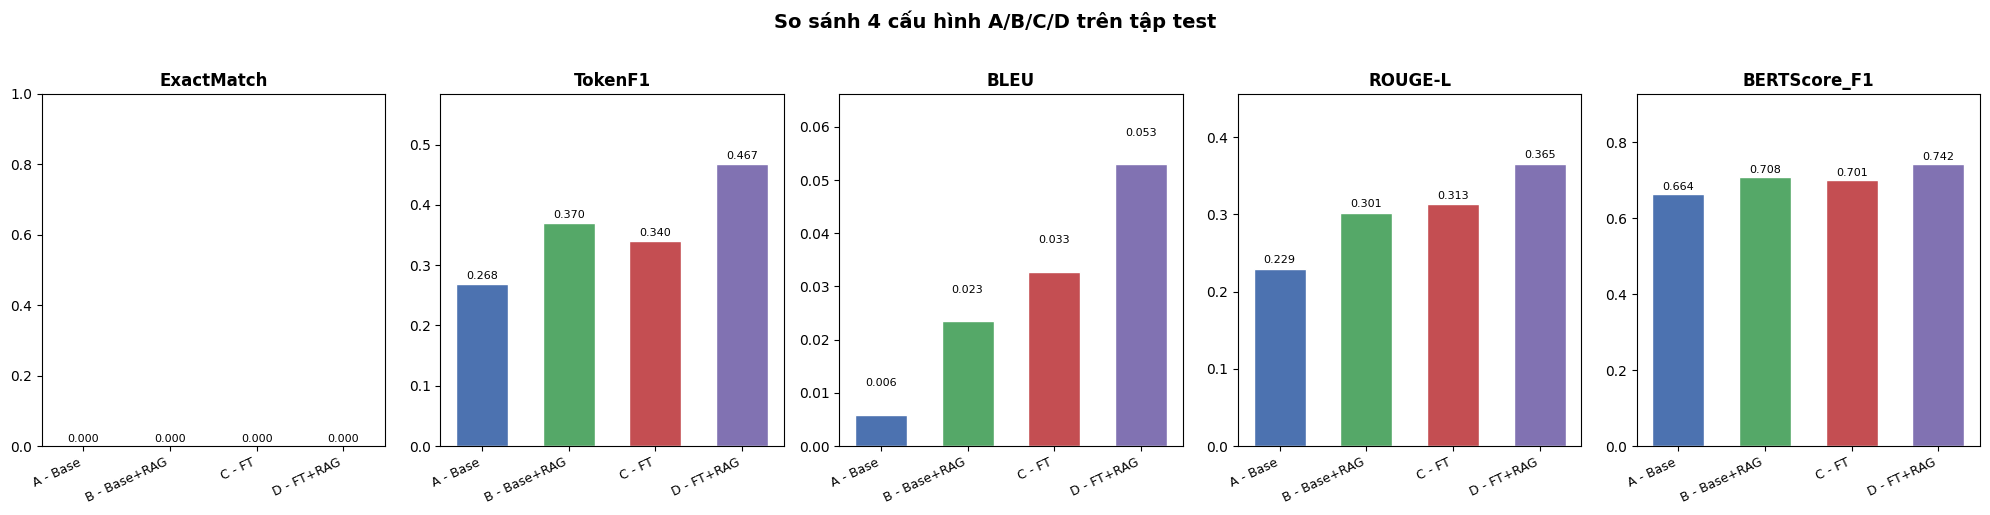

Chart saved → trafficlaw_rag\outputs\eval_comparison_chart.png

=== Recall@5 trên tập test ===
Recall@5: 1.0000


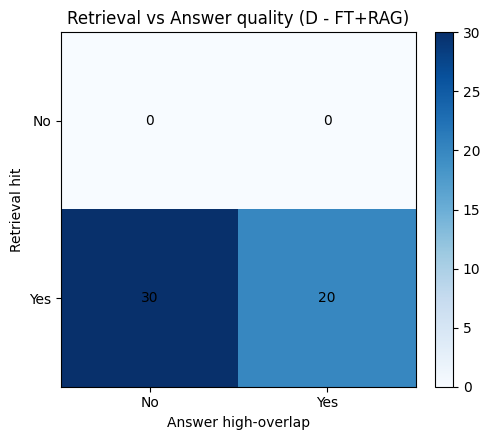

In [24]:
# ── Biểu đồ so sánh metrics giữa 4 cấu hình ────────────────────────────────
metric_cols = [c for c in ["ExactMatch", "TokenF1", "BLEU", "ROUGE-L", "BERTScore_F1"]
               if c in summary_df.columns]

n_metrics = len(metric_cols)
fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 5), sharey=False)
if n_metrics == 1:
    axes = [axes]

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
configs = summary_df.index.tolist()

for ax, metric in zip(axes, metric_cols):
    values = summary_df[metric].values
    bars = ax.bar(configs, values, color=colors[:len(configs)], edgecolor="white", width=0.6)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticklabels(configs, rotation=25, ha="right", fontsize=9)
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("So sánh 4 cấu hình A/B/C/D trên tập test",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "eval_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {OUT_DIR / 'eval_comparison_chart.png'}")

# ── Recall@5 ────────────────────────────────────────────────────────────────
print(f"\n=== Recall@{TOP_K} trên tập test ===")
r5 = recall_at_k(eval_df, k=TOP_K)
print(f"Recall@{TOP_K}: {r5:.4f}")

# ── Retrieval × Answer quality matrix (config D - FT+RAG) ───────────────────
if "D - FT+RAG" in all_results:
    plot_retrieval_answer_matrix(
        all_results["D - FT+RAG"],
        title="Retrieval vs Answer quality (D - FT+RAG)"
    )

## 11) Human Evaluation (50 câu)

Đánh giá thủ công bởi người dùng trên 50 câu hỏi ngẫu nhiên từ tập test.
So sánh cấu hình **A - Base** (không RAG, không fine-tune) và **D - FT+RAG** (tốt nhất).

**Tiêu chí chấm điểm (thang 1–5):**
- **Relevance (Liên quan):** Câu trả lời có đúng chủ đề, đúng câu hỏi không?
- **Accuracy (Chính xác):** Nội dung có đúng với luật giao thông không?
- **Fluency (Trôi chảy):** Câu văn có tự nhiên, dễ đọc không?

In [25]:
# ── Cell 11a: Xuất 50 câu ra file Excel để chấm điểm thủ công ────────────────
try:
    import openpyxl
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openpyxl"], check=True)
    import openpyxl

N_HUMAN = 50
HUMAN_EVAL_PATH = OUT_DIR / "human_eval_form.xlsx"

# Lấy 50 câu ngẫu nhiên từ test_df
human_sample = test_df.sample(n=min(N_HUMAN, len(test_df)), random_state=SEED + 1).reset_index(drop=True)

# Chuẩn bị dữ liệu
rows = []
for i, row in tqdm(human_sample.iterrows(), total=len(human_sample), desc="Preparing human eval"):
    q = normalize_text(row["question"])
    ref = normalize_text(row.get("reference_answer", row.get("answer", "")))

    # Lấy câu trả lời từ all_results nếu đã có (tránh generate lại)
    ans_a, ans_d = "", ""
    if "A - Base" in all_results:
        match_a = all_results["A - Base"][all_results["A - Base"]["question"] == q]
        if not match_a.empty:
            ans_a = match_a.iloc[0]["pred_answer"]
    if "D - FT+RAG" in all_results:
        match_d = all_results["D - FT+RAG"][all_results["D - FT+RAG"]["question"] == q]
        if not match_d.empty:
            ans_d = match_d.iloc[0]["pred_answer"]

    # Nếu chưa có thì generate mới
    if not ans_a:
        ans_a, _ = generate_answer(base_tok, base_model, q, use_rag=False)
    if not ans_d:
        ans_d, _ = generate_answer(ft_tok, ft_model, q, use_rag=True)

    rows.append({
        "STT": i + 1,
        "Câu hỏi": q,
        "Câu trả lời chuẩn (Reference)": ref,
        "A - Base (không RAG, không FT)": ans_a,
        "D - FT+RAG (tốt nhất)": ans_d,
        # ── Cột chấm điểm cho cấu hình A ────
        "A_Relevance (1-5)": "",
        "A_Accuracy (1-5)": "",
        "A_Fluency (1-5)": "",
        # ── Cột chấm điểm cho cấu hình D ────
        "D_Relevance (1-5)": "",
        "D_Accuracy (1-5)": "",
        "D_Fluency (1-5)": "",
        "Ghi chú": "",
    })

form_df = pd.DataFrame(rows)

# Ghi ra Excel với định dạng dễ đọc
with pd.ExcelWriter(HUMAN_EVAL_PATH, engine="openpyxl") as writer:
    form_df.to_excel(writer, index=False, sheet_name="Human Eval")
    ws = writer.sheets["Human Eval"]

    # Căn chỉnh độ rộng cột
    col_widths = {
        "A": 6,   # STT
        "B": 45,  # Câu hỏi
        "C": 60,  # Reference
        "D": 55,  # A - Base
        "E": 55,  # D - FT+RAG
        "F": 18, "G": 18, "H": 18,   # Scores A
        "I": 18, "J": 18, "K": 18,   # Scores D
        "L": 30,  # Ghi chú
    }
    for col_letter, width in col_widths.items():
        ws.column_dimensions[col_letter].width = width

    # Wrap text cho cột nội dung
    from openpyxl.styles import Alignment, PatternFill, Font
    wrap = Alignment(wrap_text=True, vertical="top")
    header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
    score_fill  = PatternFill(start_color="E2EFDA", end_color="E2EFDA", fill_type="solid")
    header_font = Font(color="FFFFFF", bold=True)

    for row in ws.iter_rows():
        for cell in row:
            cell.alignment = wrap
            if cell.row == 1:
                cell.fill = header_fill
                cell.font = header_font
            elif cell.column in range(6, 12):  # Các cột điểm (F–K)
                cell.fill = score_fill

print(f"[OK] Da xuat {len(form_df)} cau ra file: {HUMAN_EVAL_PATH}")
print()
print("Huong dan:")
print("  1. Mo file Excel tren va dien diem vao 6 cot mau xanh la (A_Relevance, A_Accuracy, A_Fluency, D_Relevance, D_Accuracy, D_Fluency)")
print("  2. Thang diem 1-5: 1=Rat kem, 2=Kem, 3=Trung binh, 4=Tot, 5=Rat tot")
print("  3. Luu file va chay cell tiep theo de tong hop ket qua")

Preparing human eval:   0%|          | 0/50 [00:00<?, ?it/s]

[OK] Da xuat 50 cau ra file: trafficlaw_rag\outputs\human_eval_form.xlsx

Huong dan:
  1. Mo file Excel tren va dien diem vao 6 cot mau xanh la (A_Relevance, A_Accuracy, A_Fluency, D_Relevance, D_Accuracy, D_Fluency)
  2. Thang diem 1-5: 1=Rat kem, 2=Kem, 3=Trung binh, 4=Tot, 5=Rat tot
  3. Luu file va chay cell tiep theo de tong hop ket qua


In [ ]:
# ── Cell 11b: Tổng hợp kết quả sau khi chấm điểm thủ công ───────────────────
# Chạy cell này SAU KHI đã điền điểm vào file Excel

HUMAN_EVAL_PATH = OUT_DIR / "human_eval_form.xlsx"

try:
    scored_df = pd.read_excel(HUMAN_EVAL_PATH, sheet_name="Human Eval")
except FileNotFoundError:
    print("[ERROR] Chua tim thay file. Hay chay Cell 11a truoc.")
    raise

score_cols_a = ["A_Relevance (1-5)", "A_Accuracy (1-5)", "A_Fluency (1-5)"]
score_cols_d = ["D_Relevance (1-5)", "D_Accuracy (1-5)", "D_Fluency (1-5)"]

# Chỉ tính trên các dòng đã được chấm điểm
scored = scored_df.dropna(subset=score_cols_a + score_cols_d)
n_scored = len(scored)

if n_scored == 0:
    print("[WARNING] Chua co dong nao duoc cham diem. Hay dien diem vao file Excel truoc.")
else:
    print(f"Da cham diem: {n_scored}/{len(scored_df)} cau")

    # Tính trung bình từng tiêu chí
    human_summary = pd.DataFrame({
        "Config": ["A - Base", "D - FT+RAG"],
        "Relevance (avg)": [
            scored["A_Relevance (1-5)"].mean(),
            scored["D_Relevance (1-5)"].mean(),
        ],
        "Accuracy (avg)": [
            scored["A_Accuracy (1-5)"].mean(),
            scored["D_Accuracy (1-5)"].mean(),
        ],
        "Fluency (avg)": [
            scored["A_Fluency (1-5)"].mean(),
            scored["D_Fluency (1-5)"].mean(),
        ],
    })
    human_summary["Overall (avg)"] = human_summary[["Relevance (avg)", "Accuracy (avg)", "Fluency (avg)"]].mean(axis=1)
    human_summary = human_summary.set_index("Config")

    print("\n=== Ket qua Human Evaluation ===")
    display(human_summary.round(3))

    # ── Biểu đồ radar / bar chart so sánh ───────────────────────────────────
    criteria   = ["Relevance (avg)", "Accuracy (avg)", "Fluency (avg)"]
    x          = range(len(criteria))
    width      = 0.35
    vals_a     = [human_summary.loc["A - Base", c]     for c in criteria]
    vals_d     = [human_summary.loc["D - FT+RAG", c]  for c in criteria]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars_a = ax.bar([i - width/2 for i in x], vals_a, width, label="A - Base",    color="#4C72B0", edgecolor="white")
    bars_d = ax.bar([i + width/2 for i in x], vals_d, width, label="D - FT+RAG", color="#55A868", edgecolor="white")

    ax.set_xticks(list(x))
    ax.set_xticklabels(["Relevance\n(Lien quan)", "Accuracy\n(Chinh xac)", "Fluency\n(Troi chay)"], fontsize=11)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("Diem trung binh (1-5)", fontsize=11)
    ax.set_title("Human Evaluation: A - Base vs D - FT+RAG", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.axhline(y=3, color="gray", linestyle="--", alpha=0.5, label="Nguong trung binh (3)")

    for bar in bars_a + bars_d:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    out_img = OUT_DIR / "human_eval_chart.png"
    plt.savefig(out_img, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved -> {out_img}")

    # Lưu bảng kết quả
    human_summary.to_csv(OUT_DIR / "human_eval_summary.csv", encoding="utf-8-sig")
    print("Human eval summary saved.")